<a href="https://colab.research.google.com/github/emisseldine/MisselBooks/blob/main/LinearAlgebra/workbooks/matrixapp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<p style="text-align:center">
    <a href="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" target="_blank">
    <img src="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" width="200" alt="Missel Books Logo">
    </a>
</p>


# 3.2 Matrix Applications
</center>

---


*An example is provided in Exercise 0. To execute your code, hit the play/execute/run button or Shift+Enter.*


0.   Given an $n$-vector $\boldsymbol x$, find an $(n-2)\times n$ matrix $A$ which *trims the vectors*, that is, $A\boldsymbol x = (x_2, \ldots, x_{n-1})$.


In [1]:
import numpy as np

### EXERCISE 1#######################################
print('A = [0, I_{n-2}, 0]\n')

x = np.array(np.arange(np.random.randint(10,100))) #creates a vector of random length
A = np.hstack((np.zeros((len(x)-2,1)),np.identity(len(x)-2),np.zeros((len(x)-2,1))))
print(x,'\n',(A@x).flatten()) #reshape from a column vector to a row vector

A = [0, I_{n-2}, 0]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86] 
 [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85.]


1.  Given a time series $\boldsymbol t$ of even length $n$, find an $\dfrac{n}{2}\times n$ matrix $A$ which *down samples* the time series by a factor of 2, that is, $A\boldsymbol t = \left(t_2, t_4, t_6, \ldots, t_n\right)$.


In [ ]:
e = lambda i,n: np.eye(1,n,i) #returns unit vector e_i of length n
print(e(2,3)) #e_1 of length 3

### EXERCISE 2#######################################
print('solution\n')

x = np.array(np.arange(2*np.random.randint(5,50))) #creates a vector of random even length
A = #down samples matrix
print(x,'\n',(A@x).flatten())

<details><summary>Click here for the solution</summary>

$A = \left[\boldsymbol 0, \boldsymbol e_1, \boldsymbol 0, \boldsymbol e_2, \boldsymbol 0, \boldsymbol e_3, \ldots, \boldsymbol 0, \boldsymbol e_{\tfrac{n}{2}}\right]$

```Python
n = len(x)//2
A = np.vstack([np.vstack((np.zeros(n),e(i,n))) for i in range(n)]).T
```
</details>

3.  Given a time series $\boldsymbol t$ of length $n$, find a $(2n-1)\times n$ matrix $A$ which *up samples* the time series by a factor of 2, that is, $A\boldsymbol t = \left(t_1, \dfrac{t_1+t_2}{2}, t_2, \dfrac{t_2+t_3}{2}, t_3, \ldots, t_{n-1}, \dfrac{t_{n-1}+t_n}{2}, t_n\right)$.


In [ ]:
### EXERCISE 3#######################################
print('solution\n')

x = np.array(np.arange(np.random.randint(10,100))) #creates a vector of random length
n = 2*len(x)-1
A = np.vstack(([e(0,n)+e(1,n)/2],
               [e(2*i,n)+(e(2*i-1,n)+e(2*i+1,n))/2 for i in range(1,len(x)-1)],
               [e(n-1,n)+e(n-2,n)/2])).T
print(x,'\n',(A@x).flatten())

<details><summary>Click here for the solution</summary>

$A=\left[\boldsymbol e_1+\frac{1}{2}\boldsymbol e_2, \frac{1}{2}\boldsymbol e_2+\boldsymbol e_3 +\frac{1}{2}\boldsymbol e_4, \frac{1}{2}\boldsymbol e_4+\boldsymbol e_5+\frac{1}{2}\boldsymbol e_6,\ldots, \frac{1}{2}\boldsymbol e_{2n-4} + \boldsymbol e_{2n-3} + \frac{1}{2}\boldsymbol e_{2n-2}, \frac{1}{2}\boldsymbol e_{2n-2} + \boldsymbol e_{2n-1}\right]$

```Python
n = 2*len(x)-1
A = np.vstack(([e(0,n)+e(1,n)/2],
               [e(2*i,n)+(e(2*i-1,n)+e(2*i+1,n))/2 for i in range(1,len(x)-1)],
               [e(n-1,n)+e(n-2,n)/2])).T
```

</details>

3.  Using the adjacency matrix for the graph below, compute the number of walks from $A$ to $D$ of length 10 and the number of walks from $B$
 to $F$ of length 20.

<center>

 ![An undirected graph with six vertices labeled A, B, C, D, E, and F, containing seven edges in total. The graph forms a symmetrical bowtie shape consisting of two three-vertex triangles connected by a central horizontal bridge edge between vertex A and vertex D. The left triangle is formed by vertices A, B, and C with edges connecting A to B, B to C, and C to A. The right triangle is formed by vertices D, E, and F with edges connecting D to E, E to F, and F to D. Vertices A and D each have a degree of 3, while vertices B, C, E, and F each have a degree of 2. In terms of adjacency and network flow, the edge between A and D acts as the sole bottleneck connecting the two closed sub-networks ABC and DEF. For an adjacency matrix ordered A through F, row A has non-zero entries in columns B, C, and D; row B in columns A and C; row C in columns A and B; row D in columns A, E, and F; row E in columns D and F; and row F in columns D and E.](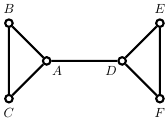)

</center>

In [ ]:
### EXERCISE 3#######################################
#the adjacency matrix of graph G
AG = np.array([[0,1,1,1,0,0],#A
              [1,0,1,0,0,0],#B
              [1,1,0,0,0,0],#C
              [1,0,0,0,1,1],#D
              [0,0,0,1,0,1],#E
              [0,0,0,1,1,0]])#F
#compute A^10
print("The number of paths from A to D of length 10 is ", )
#what from A^10 tells us about the paths from A to D of length 10?
print('solution?')

#next, compute A^20 and find the number of paths from B to F of length 20.
print("The number of paths from B to F of length 20 is ", )

<details><summary>Click here for the solution</summary>

```Python
print("The number of paths from A to D of length 10 is ", 1560)
print("The number of paths from B to F of length 20 is ", 5640122)
```

</details>

4. For the following time series, smooth the series using the probabilities $\boldsymbol p = [1/3, 1/3, 1/3], [1/6, 2/3, 1/6], [1/4, 1/2, 1/4], [1/5, 1/5, 1/5, 1/5, 1/5], [1/16, 1/4, 3/8, 1/4, 1/16]$, and $[1/8, 1/8, 1/2, 1/8, 1/8]$. Submit a graphic for the original line graph and all six possible smoothings. Make some observations and guesses about how the probability vector affects the smoothing process.

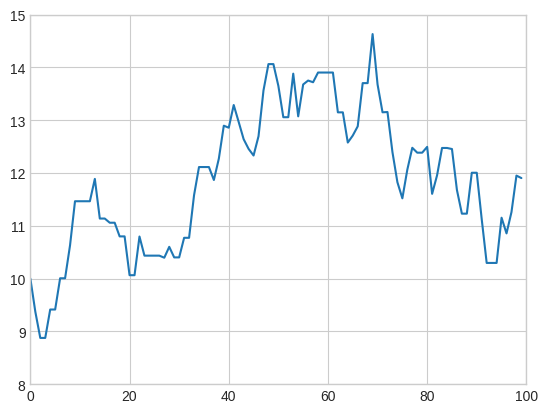

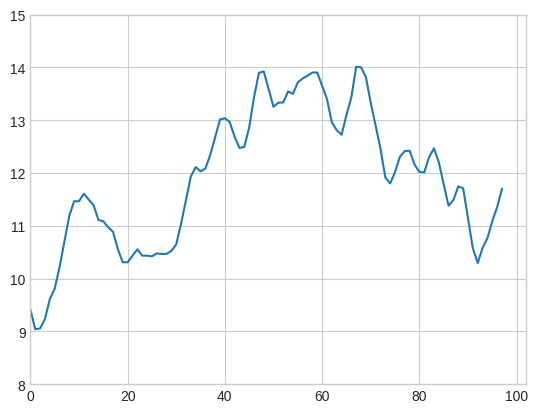

In [2]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

#the time series
X = np.array([10,9.371811379420594,8.875298622037981,8.875298622037981,9.413188493680384,9.413188493680384,
              10.005260023166363,10.005260023166363,10.62924298508378,11.464006184635922,11.464006184635922,
              11.464006184635922,11.464006184635922,11.887537216409891,11.136357062824521,11.136357062824521,
              11.057236630582612,11.057236630582612,10.798318071238844,10.798318071238844,10.063193063599943,
              10.063193063599943,10.796002894317288,10.43359762177321,10.43359762177321,10.43359762177321,
              10.43359762177321,10.394463477531714,10.600431329399168,10.400426591397789,10.400426591397789,
              10.771488728209894,10.771488728209894,11.577428139463887,12.111630742901735,12.111630742901735,
              12.111630742901735,11.866406250515109,12.271076219242298,12.89479859610239,12.856672009243878,
              13.286290696282679,12.96551346165231,12.639422476641586,12.455528414123775,12.329913288075115,
              12.695004069851635,13.561852105032148,14.061248398716605,14.061248398716605,13.648903814339857,
              13.055503739700121,13.055503739700121,13.880262477461535,13.071931815648279,13.675560912985013,
              13.749740729848668,13.717702822891262,13.90157793563202,13.90157793563202,13.90157793563202,
              13.90157793563202,13.147497519777575,13.147497519777575,12.575565131897557,12.707883909724249,
              12.882675782526304,13.701097368923673,13.701097368923673,14.630008125430347,13.676289173463838,
              13.148556398889397,13.153805401097026,12.395273542254046,11.824495878620004,11.518982735863297,
              12.062092410196717,12.476569666258783,12.383819715681016,12.383819715681016,12.493781195029124,
              11.603802562792879,11.95629293894893,12.473014374446954,12.473014374446954,12.452996449041787,
              11.677758550423894,11.228792060302096,11.228792060302096,12.003606594060193,12.003606594060193,
              11.123108018696819,10.295494633158782,10.295494633158782,10.295494633158782,11.151995486321882,
              10.854998525756114,11.25897818776794,11.949393024607282,11.902840036110444])
#graph X
plt.plot(range(len(X)), X)
plt.xlim(0,len(X))
plt.ylim(8, 15)
plt.show()

#convolution by [1/3, 1/3, 1/3]
Y = np.convolve(X, [1/3, 1/3, 1/3])
plt.plot(range(98), Y[2:100])   #You need to trim off the first and last two terms as they
plt.xlim(0,len(Y))              #behave weird.
plt.ylim(8, 15)
plt.show()

#Now, convolve by [1/6, 2/3, 1/6], [1/4, 1/2, 1/4], [1/5, 1/5, 1/5, 1/5, 1/5],
#[1/16, 1/4, 3/8, 1/4, 1/16], and [1/8, 1/8, 1/2, 1/8, 1/8].

#Make some observations and guesses about how the probability vector
#affects the smoothing process.
print()

---
*When completed, convert your .ipynb notebook into an .html webpage and upload it to the course's learning management system, e.g. Canvas.*
<details><summary> Instructions to convert to .html </summary>

1. *Download the .ipynb notebook, which you want to convert, on your local computer.*
2. *Run the code below to upload the .ipynb notebook.*
3. *The .html webpage will be downloaded automatically on your local machine.*

</details>

In [ ]:
from google.colab import files
f = files.upload()
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])
files.download(file0[:-5]+"html")



---
<center>

##### This Python workbook was produced for [Linear Algebra Done Openly](https://github.com/emisseldine/MisselBooks/tree/main/LinearAlgebra) by Dr. Andrew Misseldine (2026).
<p style="text-align:center">
    <a href="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" target="_blank">
    <img src="https://raw.githubusercontent.com/emisseldine/OpenLinear/main/BackMatter/logo.png" width="200" alt="Missel Books Logo">
    </a>
</p>
</center>